In [7]:
%matplotlib inline
import torch
from torch.distributions import multinomial
import sys
sys.path.append('../')
from utils.utils import set_figsize
from matplotlib import  pyplot as plt

In [8]:
fair_probs = torch.ones([6]) / 6
multinomial.Multinomial(1, fair_probs).sample()

tensor([0., 0., 0., 1., 0., 0.])

In [9]:
multinomial.Multinomial(10, fair_probs).sample()

tensor([1., 1., 2., 1., 4., 1.])

In [10]:
counts = multinomial.Multinomial(1000, fair_probs).sample()
counts / 1000

tensor([0.1600, 0.1580, 0.1590, 0.1730, 0.1870, 0.1630])

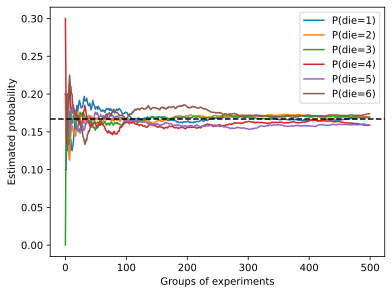

In [11]:
counts = multinomial.Multinomial(10, fair_probs).sample((500,))
cum_counts = counts.cumsum(dim=0)
estimates = cum_counts / cum_counts.sum(dim=1, keepdims=True)

set_figsize((6, 4.5))
for i in range(6):
    plt.plot(estimates[:, i].numpy(),
                 label=("P(die=" + str(i + 1) + ")"))
plt.axhline(y=0.167, color='black', linestyle='dashed')
plt.gca().set_xlabel('Groups of experiments')
plt.gca().set_ylabel('Estimated probability')
plt.legend();
